# 07 · Linear Regression

**Difficulty:** Intermediate | **Time:** ~3 hours

Linear Regression is the "Hello World" of machine learning — simple, interpretable, and powerful.

## Table of Contents
1. Theory: What Is Linear Regression?
2. Simple Linear Regression
3. Multiple Linear Regression
4. Polynomial Regression
5. Regularization: Ridge & Lasso
6. Assumptions & Diagnostics
7. Real-World Project: House Price Prediction

## 1. Theory

**Goal:** Predict a continuous number (price, temperature, sales).

**The equation:**
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n + \epsilon$$

- $\beta_0$ = intercept (where the line crosses y-axis)
- $\beta_i$ = coefficients (slope of each feature)
- $\epsilon$ = error term

**Objective:** Minimize the **Mean Squared Error (MSE)**:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Simple Linear Regression — One Feature

In [2]:
# Simulate: Study hours → Exam score
np.random.seed(42)
study_hours = np.random.uniform(1, 10, 80)
exam_score  = 50 + 5.2 * study_hours + np.random.normal(0, 5, 80)
exam_score  = exam_score.clip(0, 100)

df_simple = pd.DataFrame({'study_hours': study_hours, 'exam_score': exam_score})

# Fit model
X = df_simple[['study_hours']]
y = df_simple['exam_score']

model = LinearRegression()
model.fit(X, y)

print(f"Intercept (β₀): {model.intercept_:.2f}")
print(f"Coefficient (β₁): {model.coef_[0]:.2f}")
print(f"\nInterpretation: Each extra hour of study adds {model.coef_[0]:.2f} marks")
print(f"Prediction for 7 hours: {model.predict([[7]])[0]:.1f} marks")

Intercept (β₀): 49.28
Coefficient (β₁): 5.26

Interpretation: Each extra hour of study adds 5.26 marks
Prediction for 7 hours: 86.1 marks


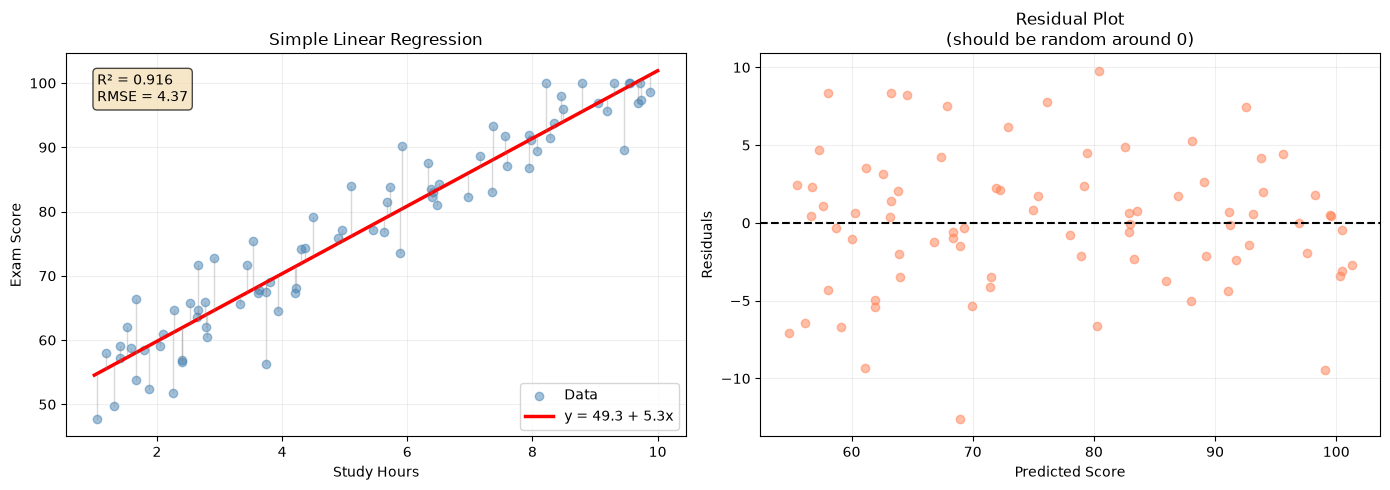

In [3]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter + regression line
x_range = np.linspace(1, 10, 100).reshape(-1, 1)
y_pred_line = model.predict(x_range)

axes[0].scatter(study_hours, exam_score, alpha=0.5, color='steelblue', label='Data')
axes[0].plot(x_range, y_pred_line, 'r-', linewidth=2.5, label=f'y = {model.intercept_:.1f} + {model.coef_[0]:.1f}x')

# Residuals (errors)
y_pred = model.predict(X)
for xi, yi, ypi in zip(study_hours, exam_score, y_pred):
    axes[0].plot([xi, xi], [yi, ypi], 'gray', alpha=0.3, linewidth=1)

axes[0].set_xlabel("Study Hours"); axes[0].set_ylabel("Exam Score")
axes[0].set_title("Simple Linear Regression"); axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Residual plot
residuals = y - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='coral')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel("Predicted Score"); axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot\n(should be random around 0)")
axes[1].grid(True, alpha=0.2)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
axes[0].text(0.05, 0.95, f'R² = {r2:.3f}\nRMSE = {rmse:.2f}',
             transform=axes[0].transAxes, fontsize=10, va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig("/tmp/lr_simple.png", dpi=100)
plt.show()

## 3. Multiple Linear Regression

In [4]:
# House price prediction — multiple features
np.random.seed(0)
n = 400
area       = np.random.randint(500, 3500, n)
bedrooms   = np.random.randint(1, 6, n)
age        = np.random.randint(0, 45, n)
distance   = np.random.randint(1, 35, n)
price      = (area*45 + bedrooms*8000 - age*1200 - distance*2500
              + np.random.normal(0, 20000, n)).clip(0)

df = pd.DataFrame({'Area':area,'Bedrooms':bedrooms,'Age':age,'Distance':distance,'Price':price})

X = df.drop('Price', axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)
y_pred = model_multi.predict(X_test)

print("Coefficients:")
for feat, coef in zip(X.columns, model_multi.coef_):
    print(f"  {feat:<12}: ₹{coef:>8,.0f} per unit")
print(f"\n  Intercept: ₹{model_multi.intercept_:,.0f}")
print(f"\nTest R² : {r2_score(y_test, y_pred):.4f}")
print(f"Test RMSE: ₹{np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")

Coefficients:
  Area        : ₹      38 per unit
  Bedrooms    : ₹   6,428 per unit
  Age         : ₹    -994 per unit
  Distance    : ₹  -2,136 per unit

  Intercept: ₹15,454

Test R² : 0.8374
Test RMSE: ₹19,217


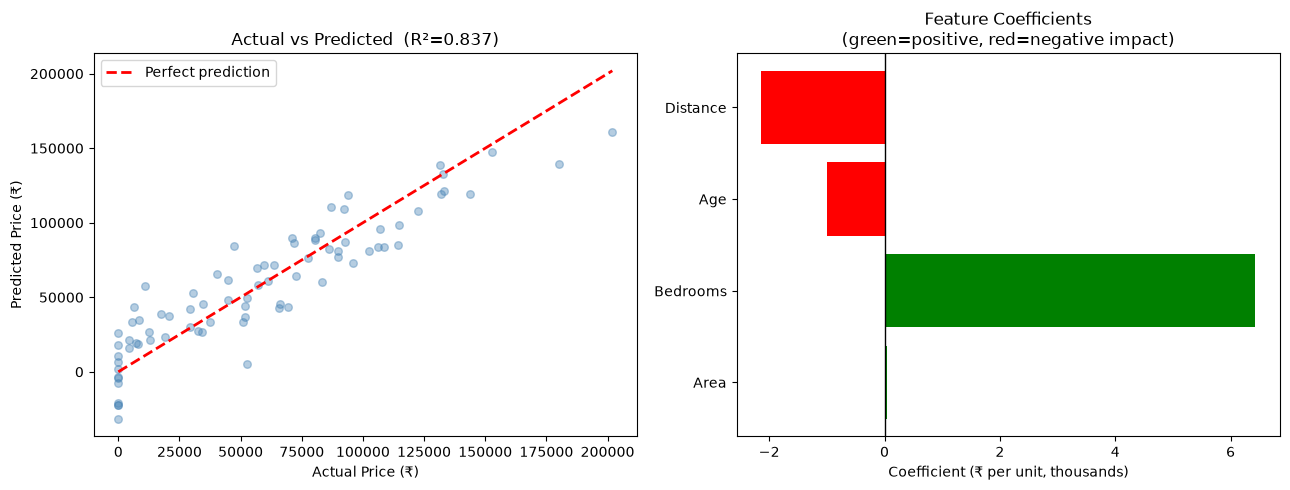

In [5]:
# Actual vs Predicted — the golden chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

perfect = np.linspace(y_test.min(), y_test.max(), 100)
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=30)
axes[0].plot(perfect, perfect, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel("Actual Price (₹)"); axes[0].set_ylabel("Predicted Price (₹)")
axes[0].set_title(f"Actual vs Predicted  (R²={r2_score(y_test,y_pred):.3f})")
axes[0].legend()

# Feature importance
coef_df = pd.DataFrame({'Feature':X.columns, 'Coefficient':model_multi.coef_})
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
axes[1].barh(coef_df['Feature'], coef_df['Coefficient']/1000, color=colors)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel("Coefficient (₹ per unit, thousands)")
axes[1].set_title("Feature Coefficients\n(green=positive, red=negative impact)")

plt.tight_layout()
plt.savefig("/tmp/lr_multiple.png", dpi=100)
plt.show()

## 4. Polynomial Regression — Non-linear Relationships

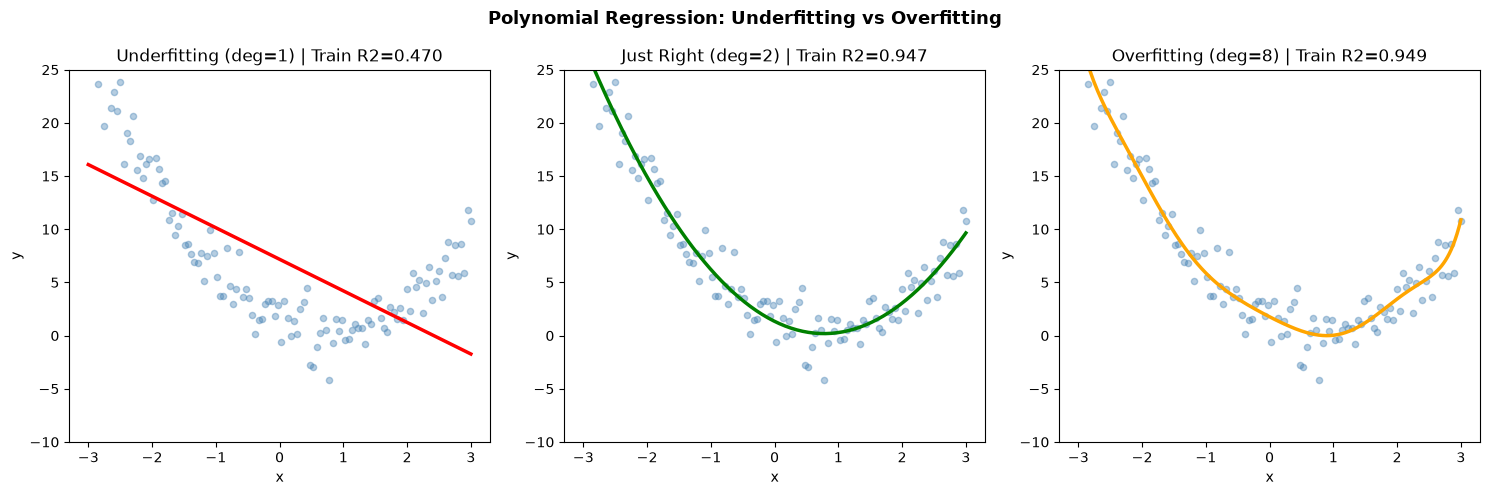

In [6]:
# When relationship is curved, not straight
np.random.seed(1)
x_poly = np.linspace(-3, 3, 120)
y_poly = 2*x_poly**2 - 3*x_poly + 1 + np.random.normal(0, 2, 120)

X_poly = x_poly.reshape(-1, 1)
x_range = np.linspace(-3, 3, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
degrees = [1, 2, 8]
titles  = ['Underfitting (deg=1)', 'Just Right (deg=2)', 'Overfitting (deg=8)']
colors  = ['red','green','orange']

for ax, deg, title, color in zip(axes, degrees, titles, colors):
    pipe = Pipeline([('poly', PolynomialFeatures(degree=deg)),
                     ('lr',   LinearRegression())])
    pipe.fit(X_poly, y_poly)
    y_fit = pipe.predict(x_range)
    train_r2 = pipe.score(X_poly, y_poly)

    ax.scatter(x_poly, y_poly, alpha=0.4, s=20, color='steelblue')
    ax.plot(x_range, y_fit, color=color, linewidth=2.5)
    ax.set_title(f"{title} | Train R2={train_r2:.3f}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_ylim(-10, 25)

plt.suptitle("Polynomial Regression: Underfitting vs Overfitting", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/lr_polynomial.png", dpi=100)
plt.show()

## 5. Regularization: Ridge & Lasso

**Why:** Prevents overfitting by penalizing large coefficients.

- **Ridge (L2):** Adds $\lambda \sum \beta_i^2$ — shrinks all coefficients, keeps all features
- **Lasso (L1):** Adds $\lambda \sum |\beta_i|$ — shrinks some to exactly 0 (feature selection!)

In [7]:
from sklearn.linear_model import RidgeCV, LassoCV

# Create a dataset with many features (some irrelevant)
np.random.seed(42)
n = 200
X_reg = np.random.randn(n, 15)
# Only first 5 features matter; rest are noise
true_coefs = [4, -3, 2, 1.5, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
y_reg = X_reg @ true_coefs + np.random.normal(0, 2, n)

X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Fit models
lr    = LinearRegression().fit(X_tr, y_tr)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(X_tr, y_tr)
lasso = LassoCV(alphas=np.logspace(-3, 2, 50), cv=5, max_iter=5000).fit(X_tr, y_tr)

print(f"Linear Regression  Test R²: {lr.score(X_te, y_te):.3f}")
print(f"Ridge (α={ridge.alpha_:.3f})     Test R²: {ridge.score(X_te, y_te):.3f}")
print(f"Lasso (α={lasso.alpha_:.3f})     Test R²: {lasso.score(X_te, y_te):.3f}")
print(f"\nLasso set {(lasso.coef_==0).sum()} coefficients to exactly 0 (feature selection!)")

Linear Regression  Test R²: 0.840
Ridge (α=1.151)     Test R²: 0.842
Lasso (α=0.176)     Test R²: 0.854

Lasso set 8 coefficients to exactly 0 (feature selection!)


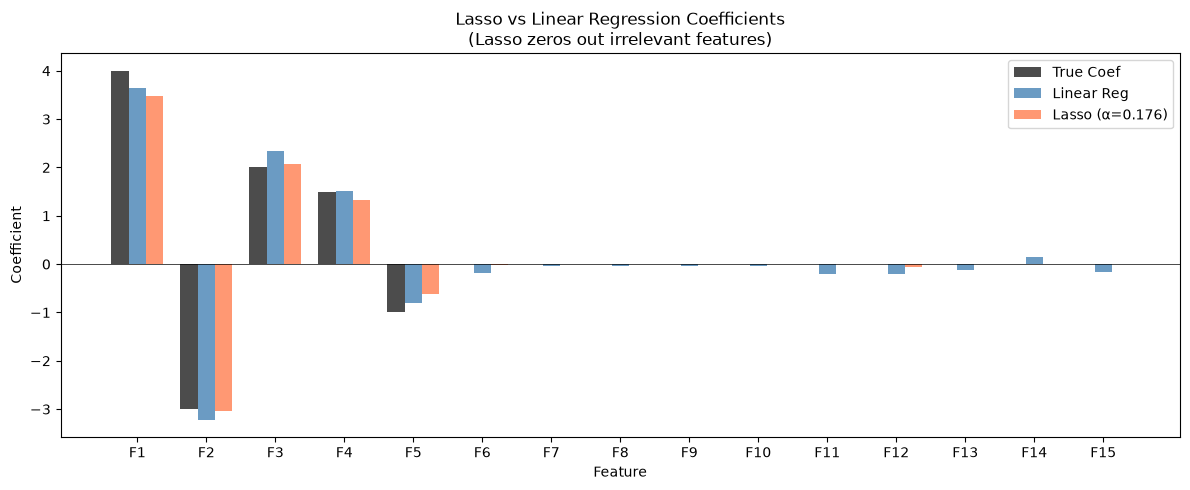

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

feat_names = [f"F{i+1}" for i in range(15)]
x_pos = np.arange(15)
width = 0.25

ax.bar(x_pos - width, true_coefs, width, label='True Coef', color='black', alpha=0.7)
ax.bar(x_pos,         lr.coef_,   width, label='Linear Reg', color='steelblue', alpha=0.8)
ax.bar(x_pos + width, lasso.coef_,width, label=f'Lasso (α={lasso.alpha_:.3f})', color='coral', alpha=0.8)

ax.set_xticks(x_pos); ax.set_xticklabels(feat_names)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel("Feature"); ax.set_ylabel("Coefficient")
ax.set_title("Lasso vs Linear Regression Coefficients\n(Lasso zeros out irrelevant features)")
ax.legend()
plt.tight_layout()
plt.savefig("/tmp/lr_regularization.png", dpi=100)
plt.show()

## 6. Model Evaluation Metrics

In [9]:
def evaluate_regression(y_true, y_pred, model_name="Model"):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    # Adjusted R²
    n_samples  = len(y_true)
    n_features = 4  # for our house dataset
    adj_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)
    
    print("="*40)
    print(f" {model_name}")
    print("="*40)
    print(f"  R2        : {r2:.4f}   (1.0 = perfect)")
    print(f"  Adj. R²   : {adj_r2:.4f}")
    print(f"  RMSE      : ₹{rmse:,.0f} (avg error magnitude)")
    print(f"  MAE       : ₹{mae:,.0f}  (avg absolute error)")
    print(f"{'='*40}")

evaluate_regression(y_test, model_multi.predict(X_test), "Multiple Linear Regression")

 Multiple Linear Regression
  R2        : 0.8374   (1.0 = perfect)
  Adj. R²   : 0.8287
  RMSE      : ₹19,217 (avg error magnitude)
  MAE       : ₹15,861  (avg absolute error)


## 7. Real-World Project: House Price Prediction

In [10]:
# Complete end-to-end house price prediction
from sklearn.model_selection import KFold

# More realistic dataset
np.random.seed(42)
n = 600
data = {
    'area'        : np.random.randint(400, 4000, n),
    'bedrooms'    : np.random.randint(1, 6, n),
    'bathrooms'   : np.random.randint(1, 4, n),
    'age'         : np.random.randint(0, 50, n),
    'distance_cbd': np.random.randint(1, 40, n),
    'parking'     : np.random.randint(0, 3, n),
    'floor'       : np.random.randint(1, 20, n),
}
houses = pd.DataFrame(data)
houses['price'] = (
    houses['area'] * 48
    + houses['bedrooms'] * 9000
    + houses['bathrooms'] * 15000
    - houses['age'] * 1800
    - houses['distance_cbd'] * 3000
    + houses['parking'] * 12000
    + houses['floor'] * 2000
    + np.random.normal(0, 30000, n)
).clip(200000, 4000000).astype(int)

X = houses.drop('price', axis=1)
y = houses['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Compare all models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=100),
    'Lasso Regression' : Lasso(alpha=100, max_iter=5000),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    test_r2   = model.score(X_test, y_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
    results.append({'Model':name, 'CV R²':cv_scores.mean(), 'Test R²':test_r2, 'Test RMSE':test_rmse})

results_df = pd.DataFrame(results)
print("Model Comparison:")
print(results_df.round(4).to_string(index=False))

Model Comparison:
            Model  CV R²  Test R²  Test RMSE
Linear Regression 0.0046   0.1822  9266.8809
 Ridge Regression 0.0229   0.1817  9269.5192
 Lasso Regression 0.0104   0.1832  9261.2670


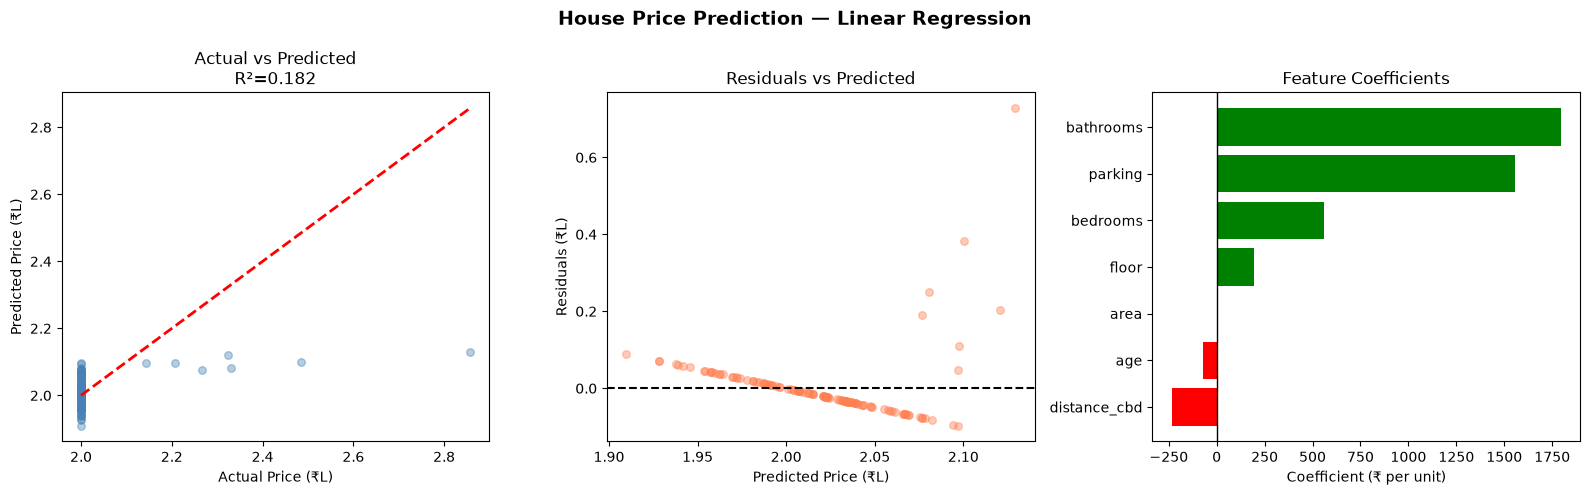

In [11]:
# Final visualization
best_model = LinearRegression().fit(X_train, y_train)
y_pred_final = best_model.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Actual vs Predicted
perfect_line = np.linspace(y_test.min(), y_test.max(), 100)
axes[0].scatter(y_test/100000, y_pred_final/100000, alpha=0.4, s=30, color='steelblue')
axes[0].plot(perfect_line/100000, perfect_line/100000, 'r--', linewidth=2)
axes[0].set_xlabel("Actual Price (₹L)"); axes[0].set_ylabel("Predicted Price (₹L)")
axes[0].set_title(f"Actual vs Predicted\nR²={r2_score(y_test,y_pred_final):.3f}")

# 2. Residuals
residuals = y_test - y_pred_final
axes[1].scatter(y_pred_final/100000, residuals/100000, alpha=0.4, s=30, color='coral')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel("Predicted Price (₹L)"); axes[1].set_ylabel("Residuals (₹L)")
axes[1].set_title("Residuals vs Predicted")

# 3. Feature importance
coef_df = pd.DataFrame({'Feature':X.columns,'Coefficient':best_model.coef_})
coef_df = coef_df.sort_values('Coefficient')
colors  = ['red' if c < 0 else 'green' for c in coef_df['Coefficient']]
axes[2].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
axes[2].axvline(0, color='black', linewidth=1)
axes[2].set_title("Feature Coefficients")
axes[2].set_xlabel("Coefficient (₹ per unit)")

plt.suptitle("House Price Prediction — Linear Regression", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/lr_project.png", dpi=100)
plt.show()

## Summary

| Model | Use When |
|---|---|
| Simple LR | 1 feature, linear relationship |
| Multiple LR | Many features, linear relationship |
| Polynomial | Curved/non-linear relationship |
| Ridge | Many features, prevent overfitting |
| Lasso | Want automatic feature selection |

**Metrics to track:** R², RMSE, MAE, Adjusted R²

**Next notebook →** `08_Logistic_Regression_Classification.ipynb`